# **Astronomy: Pulsar Candidates Classification Using Radio Emission Data**

# **Importing Relevent Libraries and Loading Dataset**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
column_names = [
    'Profile_mean', 'Profile_stdev', 'Profile_skewness', 'Profile_kurtosis',
    'DM_mean', 'DM_stdev', 'DM_skewness', 'DM_kurtosis', 'class'
]
df = pd.read_csv('HTRU_2.csv', names=column_names)



## **Data Inspection**

In [ ]:
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Profile_mean      17898 non-null  float64
 1   Profile_stdev     17898 non-null  float64
 2   Profile_skewness  17898 non-null  float64
 3   Profile_kurtosis  17898 non-null  float64
 4   DM_mean           17898 non-null  float64
 5   DM_stdev          17898 non-null  float64
 6   DM_skewness       17898 non-null  float64
 7   DM_kurtosis       17898 non-null  float64
 8   class             17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


,Profile_mean,Profile_stdev,Profile_skewness,Profile_kurtosis,DM_mean,DM_stdev,DM_skewness,DM_kurtosis,class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


# **Exploratory Data Analysis**

## **Checking Missing Values**

In [ ]:
def check_data_quality(df):
    """
    Checks for missing values and duplicate rows in the dataset.
    """
    # 1. Missing Values Calculation
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    missing_table = pd.concat([missing_count, missing_percent], axis=1, keys=['Missing Count', 'Percentage (%)'])

    print("--- Missing Values Summary ---")
    print(missing_table)

    # 2. Duplicate Rows Calculation
    duplicate_count = df.duplicated().sum()
    print(f"\n--- Duplicates Summary ---")
    print(f"Total duplicate rows identified: {duplicate_count}")

# Execute the check
check_data_quality(df)

--- Missing Values Summary ---
                  Missing Count  Percentage (%)
Profile_mean                  0             0.0
Profile_stdev                 0             0.0
Profile_skewness              0             0.0
Profile_kurtosis              0             0.0
DM_mean                       0             0.0
DM_stdev                      0             0.0
DM_skewness                   0             0.0
DM_kurtosis                   0             0.0
class                         0             0.0

--- Duplicates Summary ---
Total duplicate rows identified: 0


## **Class Distribution Analysis**

/tmp/ipython-input-3156304015.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette='viridis')


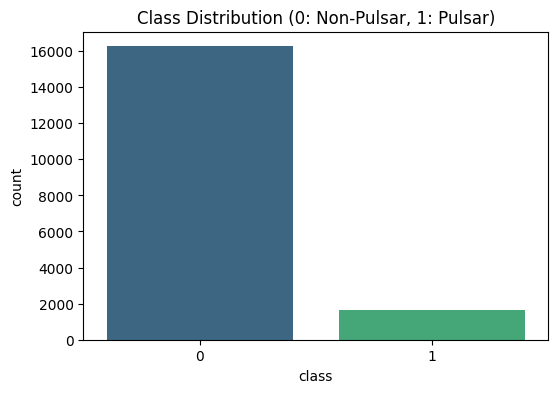

Class Counts:
 class
0    16259
1     1639
Name: count, dtype: int64

Percentage Distribution:
 class
0    90.842552
1     9.157448
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df, palette='viridis')
plt.title('Class Distribution (0: Non-Pulsar, 1: Pulsar)')
plt.show()

print("Class Counts:\n", df['class'].value_counts())
print("\nPercentage Distribution:\n", df['class'].value_counts(normalize=True) * 100)

## **Correlation Heatmap**

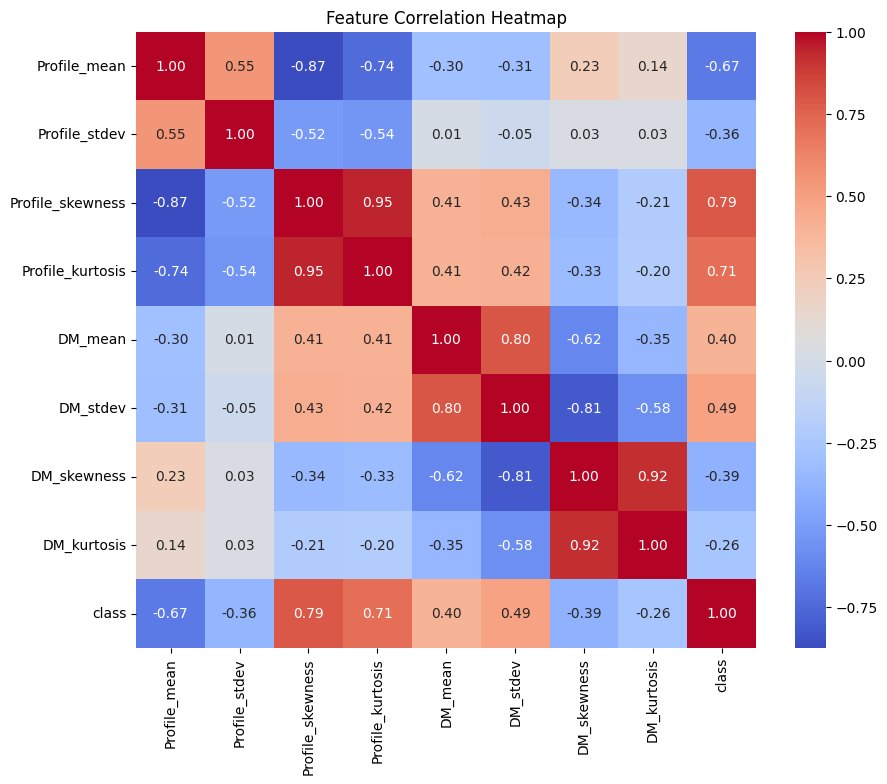

In [ ]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

## **Feature Distribution by Class (KDE Plots)**

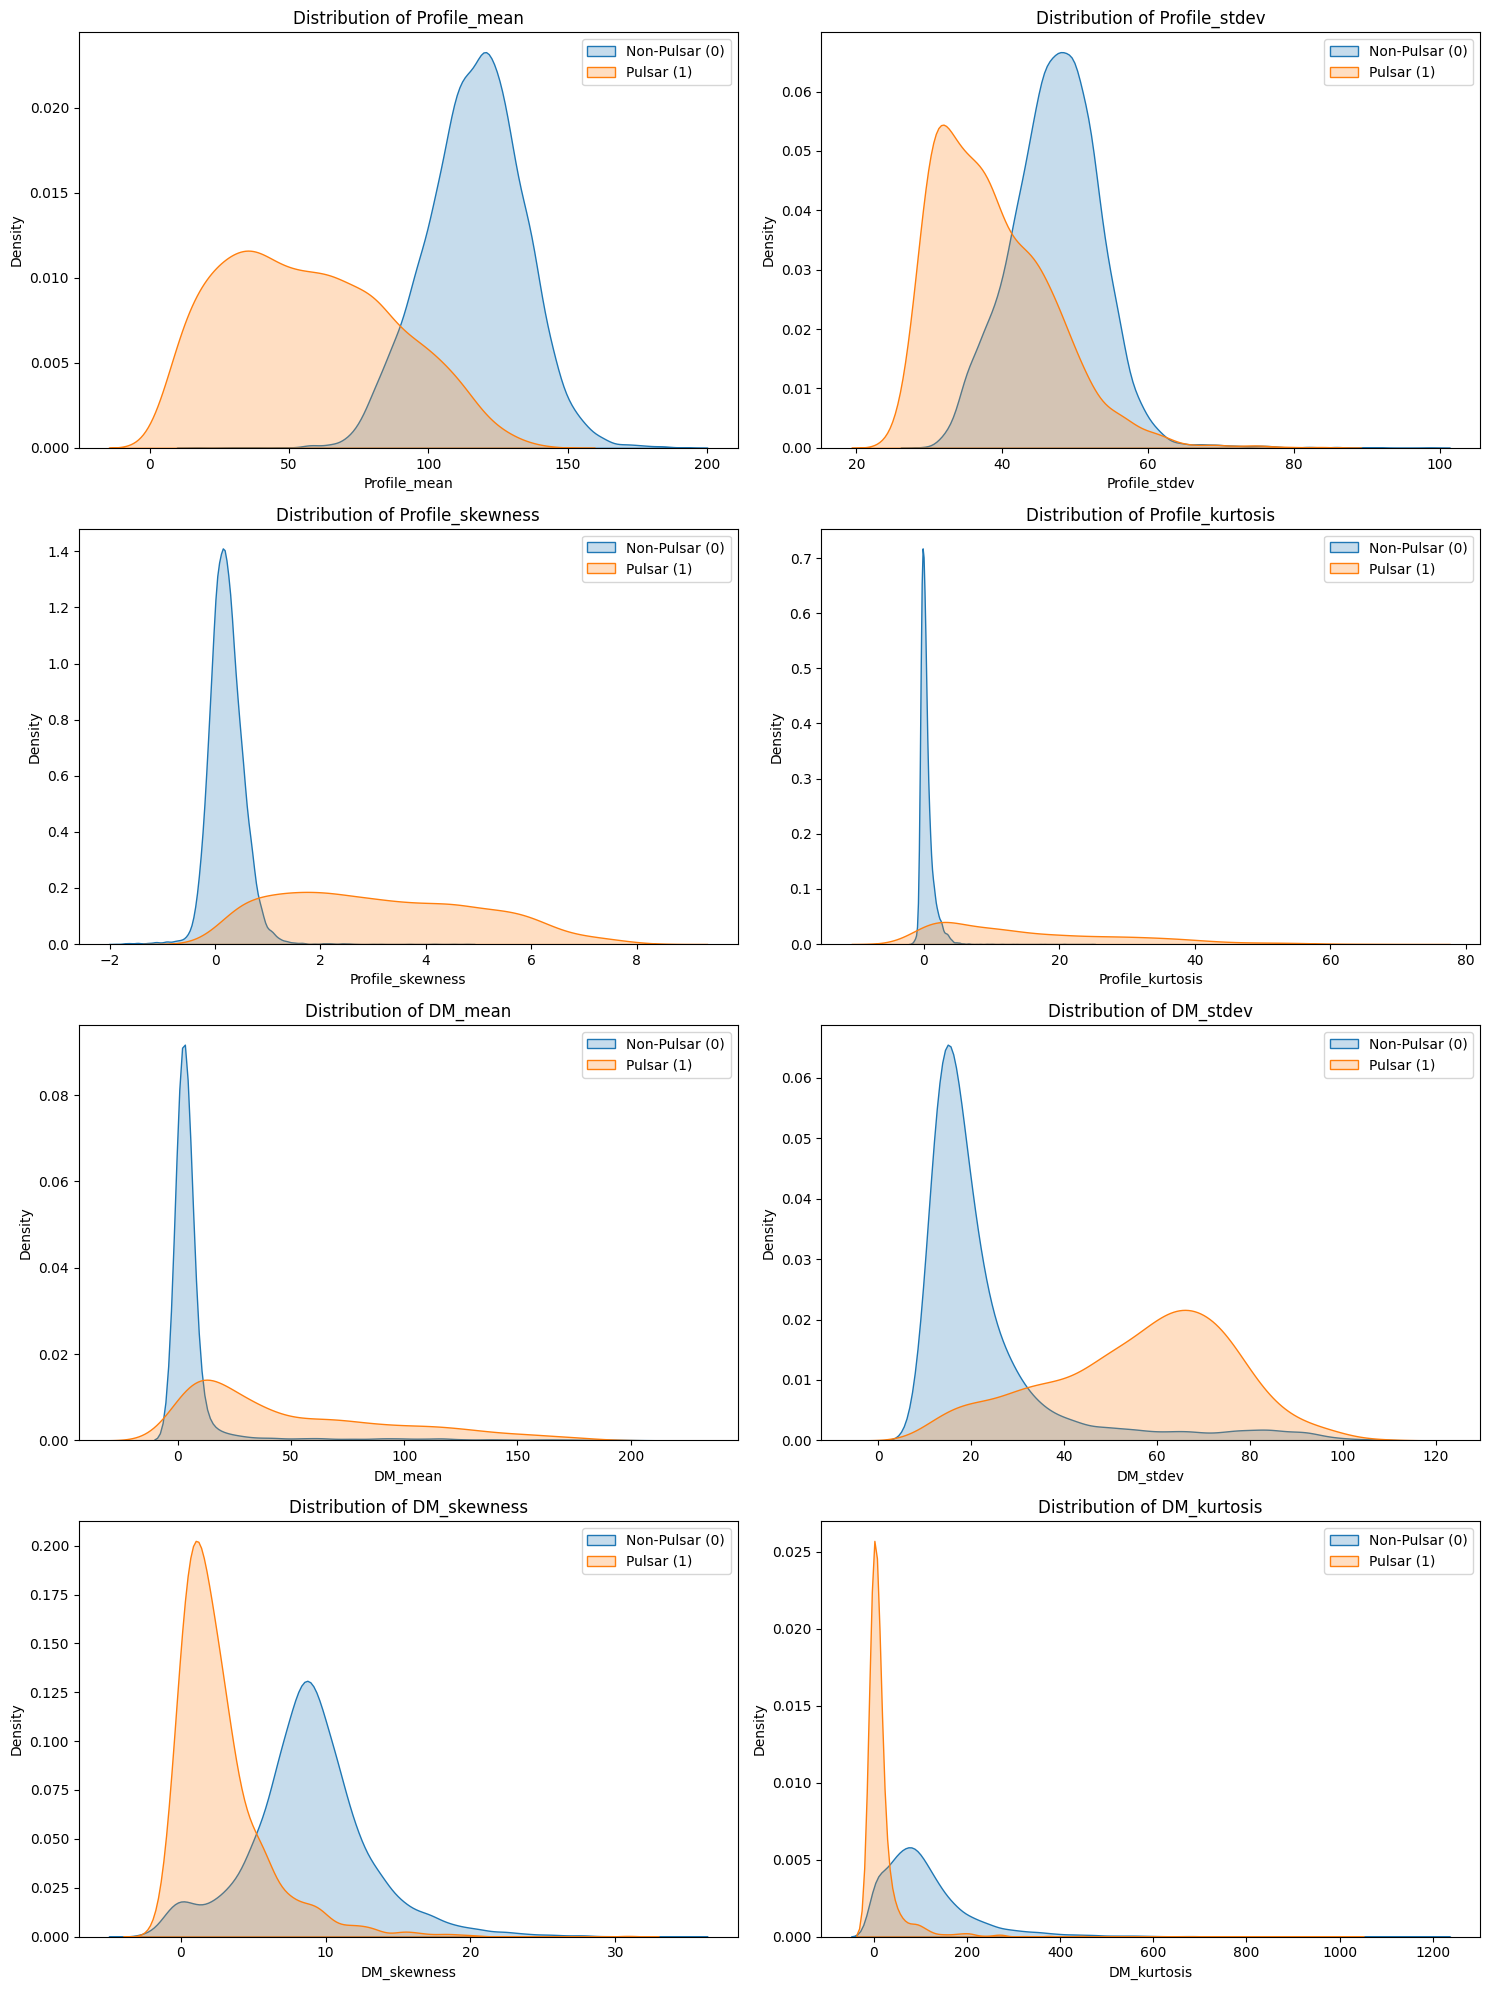

In [ ]:
features = df.columns[:-1]
plt.figure(figsize=(15, 20))
for i, col in enumerate(features):
    plt.subplot(4, 2, i + 1)
    sns.kdeplot(df[df['class'] == 0][col], label='Non-Pulsar (0)', fill=True)
    sns.kdeplot(df[df['class'] == 1][col], label='Pulsar (1)', fill=True)
    plt.title(f'Distribution of {col}')
    plt.legend()
plt.tight_layout()
plt.show()

## **Boxplots for Outlier Detection**

/tmp/ipython-input-60237468.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y=col, data=df, palette='Set2')
/tmp/ipython-input-60237468.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y=col, data=df, palette='Set2')
/tmp/ipython-input-60237468.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y=col, data=df, palette='Set2')
/tmp/ipython-input-60237468.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and se

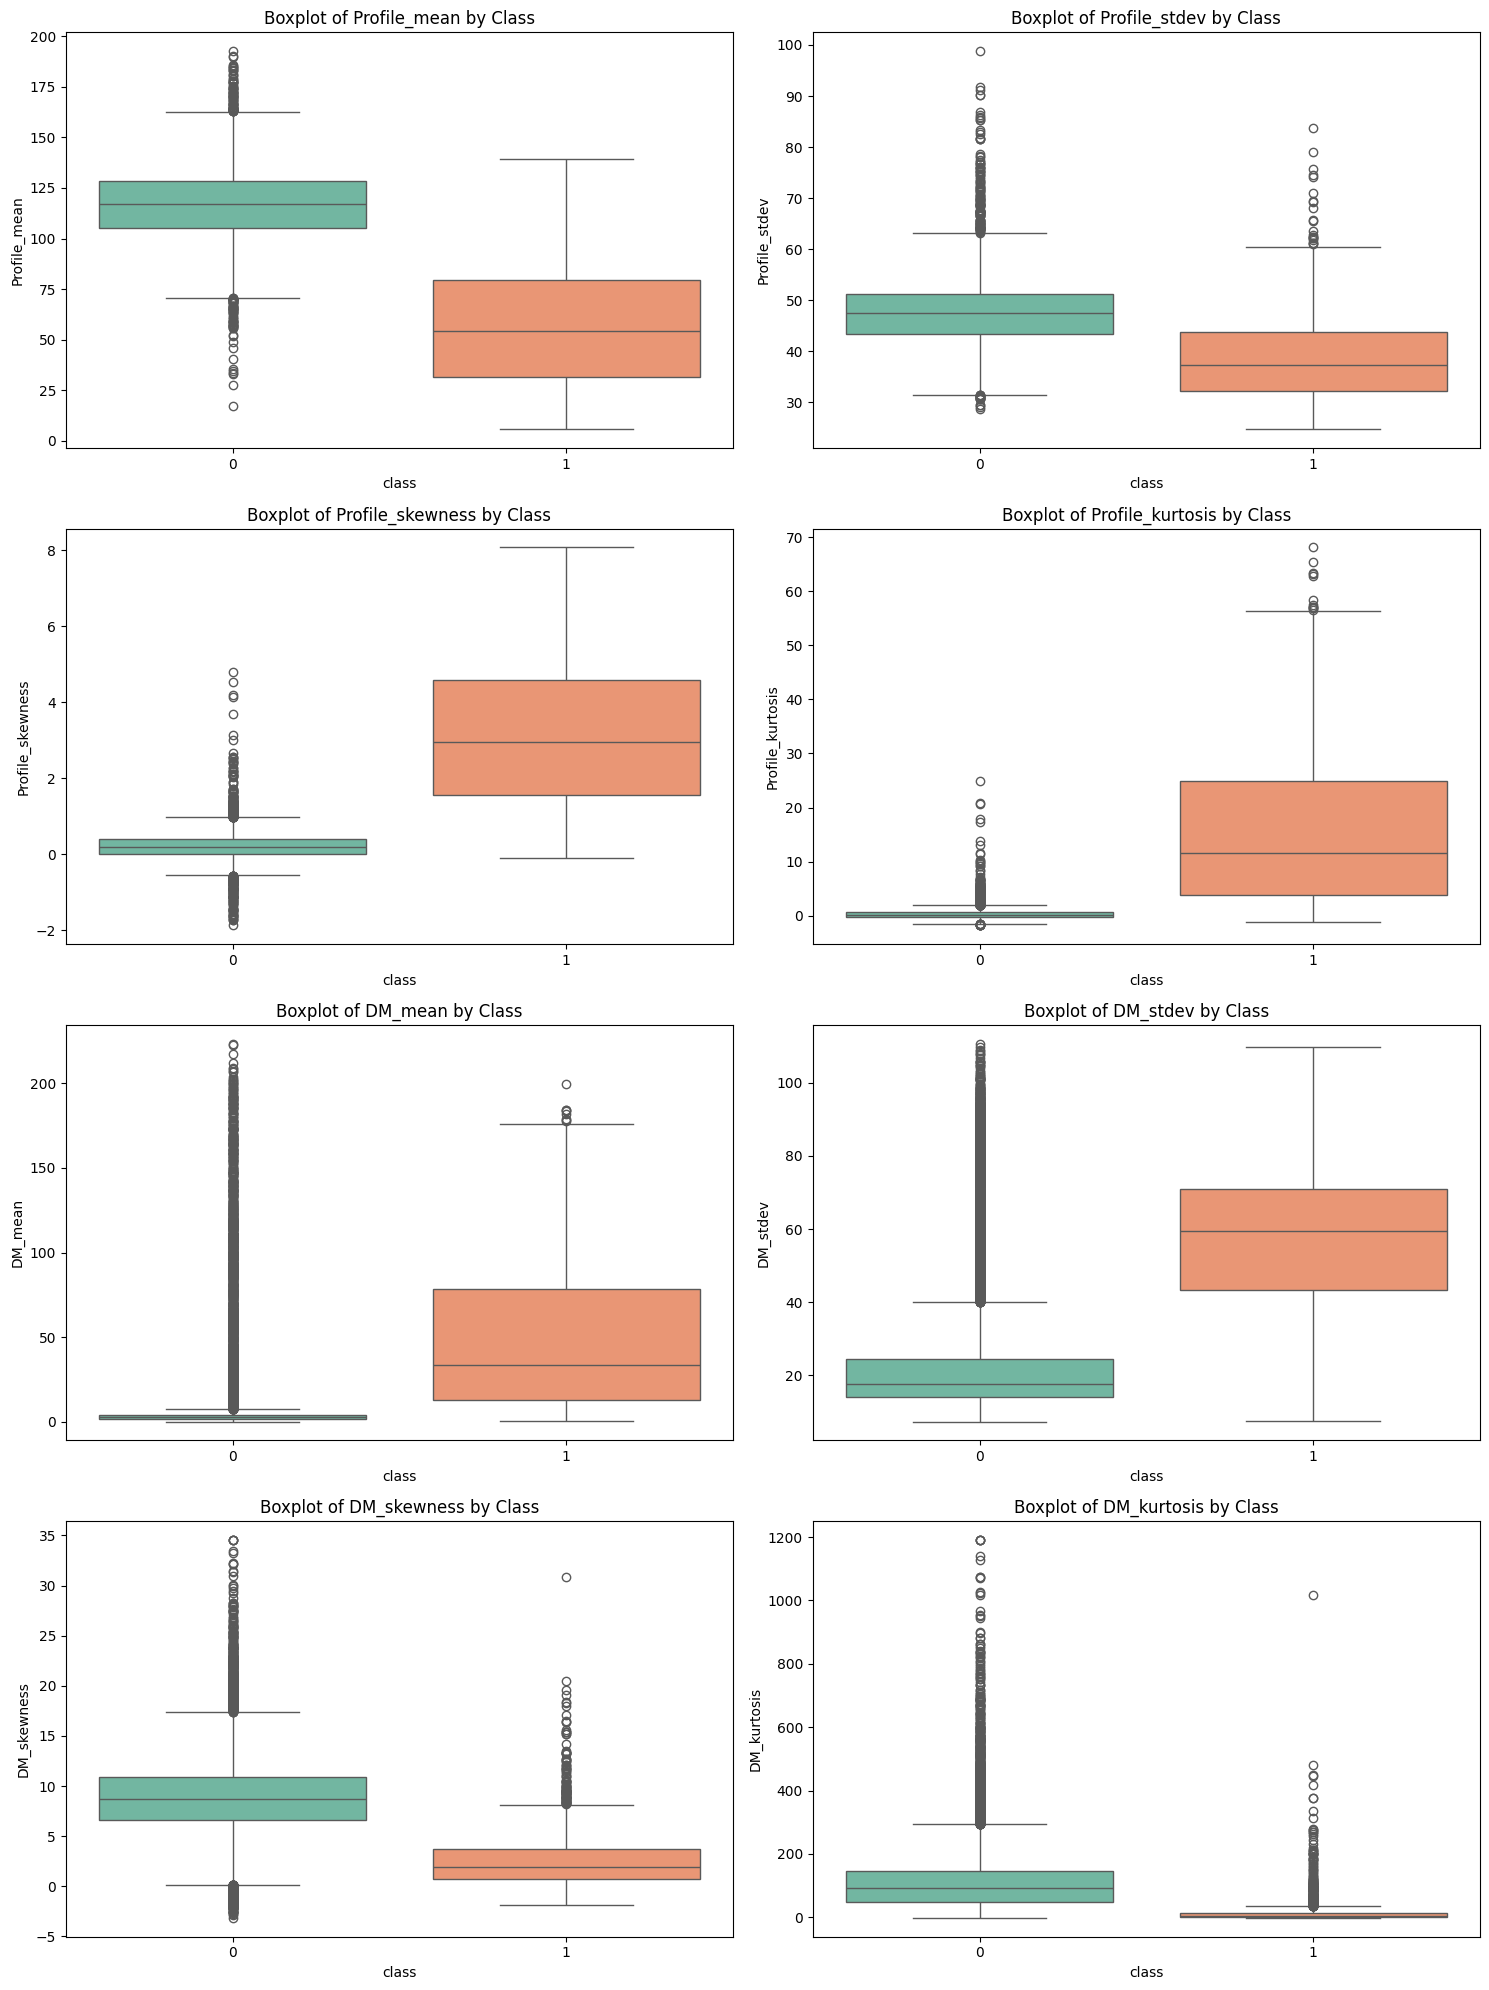

In [ ]:
plt.figure(figsize=(15, 20))
for i, col in enumerate(features):
    plt.subplot(4, 2, i + 1)
    sns.boxplot(x='class', y=col, data=df, palette='Set2')
    plt.title(f'Boxplot of {col} by Class')
plt.tight_layout()
plt.show()

## **Multivariate Analysis (Pairplot)**

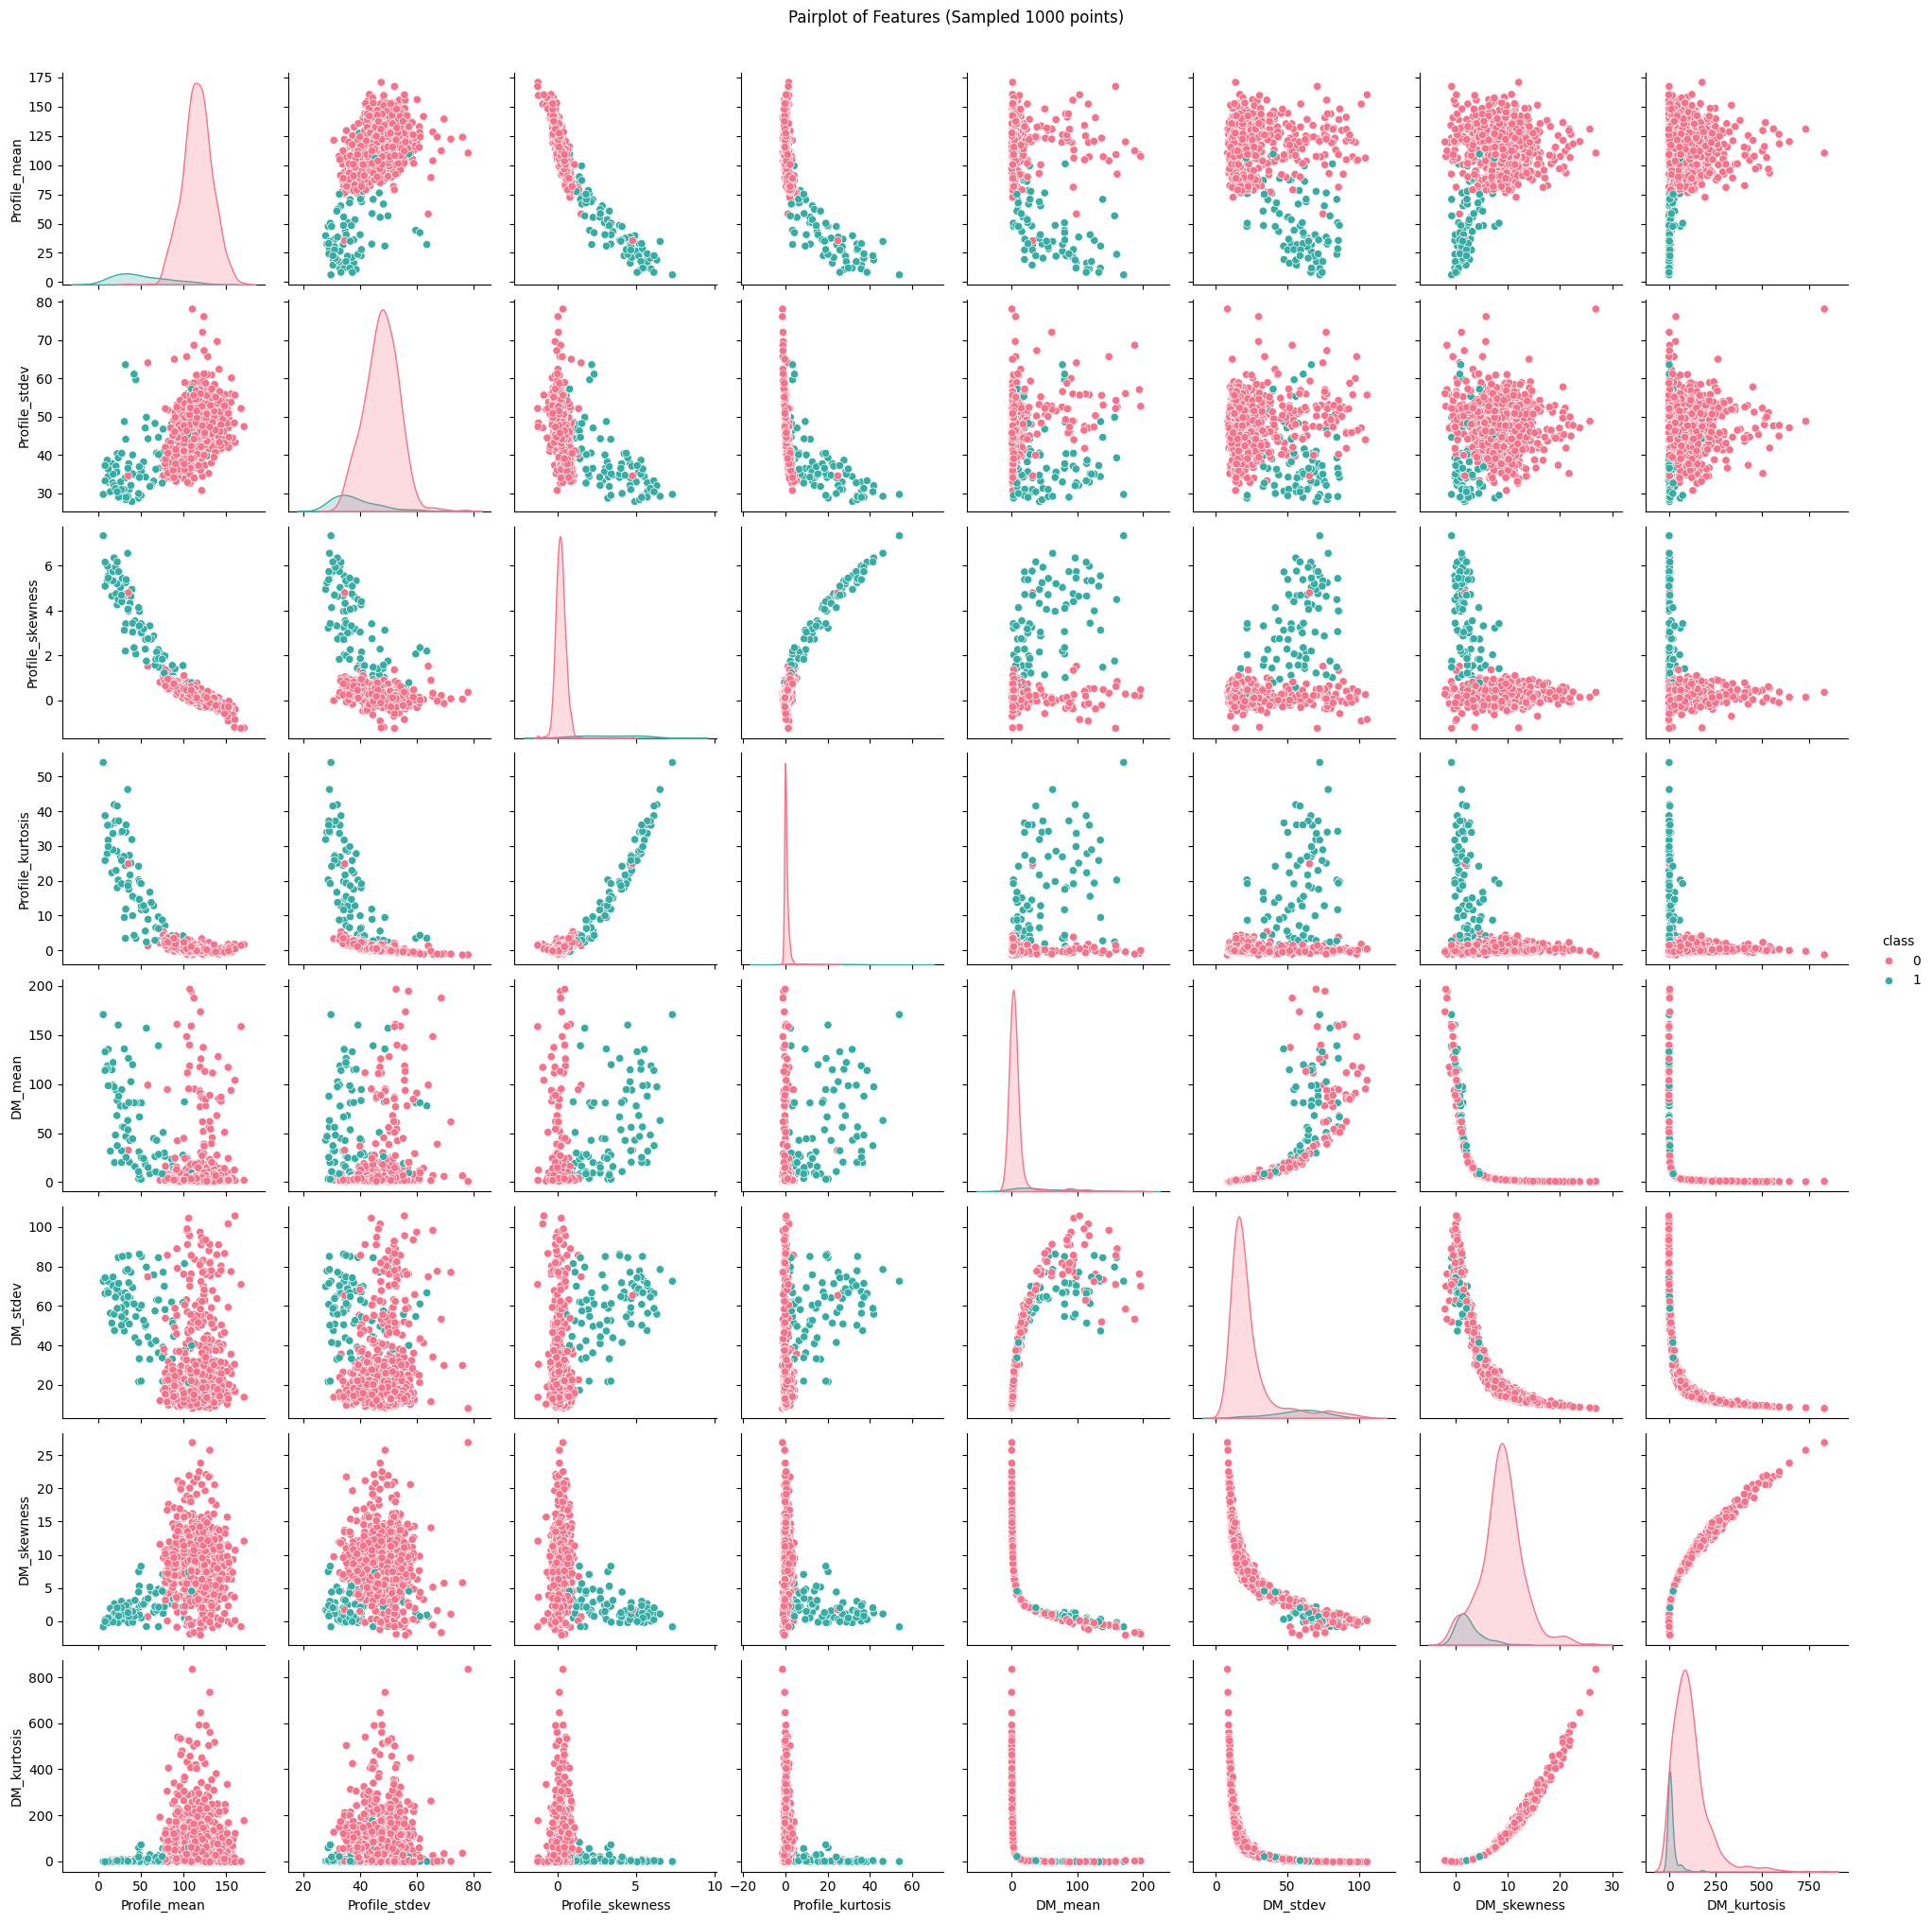

In [ ]:
# Sampling for efficiency
sample_df = df.sample(1000, random_state=42)
sns.pairplot(sample_df, hue='class', palette='husl', diag_kind='kde')
plt.suptitle('Pairplot of Features (Sampled 1000 points)', y=1.02)
plt.show()